In [ ]:
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt
import kagglehub

In [ ]:
#Data pre-processing from https://www.kaggle.com/code/shuvoalok/facial-emotion-recognition

path = kagglehub.dataset_download("shuvoalok/raf-db-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'raf-db-dataset' dataset.
Path to dataset files: /kaggle/input/raf-db-dataset


In [ ]:
train_dir = r"/kaggle/input/raf-db-dataset/DATASET/train"
test_dir = r"/kaggle/input/raf-db-dataset/DATASET/test"

In [ ]:
import os

def find_Class(directory_path):
    if not os.path.exists(directory_path):
        raise ValueError(f"The directory '{directory_path}' does not exist.")
    if not os.path.isdir(directory_path):
        raise ValueError(f"The path '{directory_path}' is not a directory.")

    all_entries = os.listdir(directory_path)
    folders = [entry for entry in all_entries if os.path.isdir(os.path.join(directory_path, entry))]
    return folders

In [ ]:
categories= []
try:
    folders = find_Class(train_dir)
    print(f"Directories in '{train_dir}':")
    for folder in folders:

      categories.append(folder)
except ValueError as e:
    print(e)

categories

Directories in '/kaggle/input/raf-db-dataset/DATASET/train':


['7', '2', '5', '3', '1', '4', '6']

In [ ]:
train_data=[]

for category in categories:
    folder=os.path.join(train_dir,category)
    label=categories.index(category)


    for img in os.listdir(folder):
        img=os.path.join(folder,img)
        img_arr=cv2.imread(img)
        if img_arr is not None:
            img_arr = cv2.resize(img_arr, (128, 128))
            train_data.append([img_arr, label])
        else:
            print(f"Failed to load image {img}")

In [ ]:
x_train=[]
y_train=[]


for features,label in train_data:
    x_train.append(features)
    y_train.append(label)

X_train = np.array(x_train)/255
y_train = np.array(y_train)
print(X_train.shape, y_train.shape)

(12271, 128, 128, 3) (12271,)


In [ ]:
test_data=[]

for category in categories:
    folder=os.path.join(test_dir,category)
    label=categories.index(category)


    for img in os.listdir(folder):
        img=os.path.join(folder,img)
        img_arr=cv2.imread(img)
        if img_arr is not None:
            img_arr = cv2.resize(img_arr, (128, 128))
            test_data.append([img_arr, label])
        else:
            print(f"Failed to load image {img}")

In [ ]:
X_test=[]
y_test=[]


for features,label in test_data:
    X_test.append(features)
    y_test.append(label)



X_test = np.array(X_test) / 255.0
y_test = np.array(y_test)
print(X_test.shape, y_test.shape)

(3068, 128, 128, 3) (3068,)


In [ ]:
from sklearn.model_selection import train_test_split

X_val, X_final_test, y_val, y_final_test = train_test_split(
    X_test, y_test, test_size=0.3, random_state=42, stratify=y_test
)

X_test = X_val
y_test = y_val

print(f"Val set for training: {X_test.shape}")
print(f"Final test set for evaluation: {X_final_test.shape}")

Val set for training: (2147, 128, 128, 3)
Final test set for evaluation: (921, 128, 128, 3)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
#Baseline Without MediaPipe -- Architecture partially from 'Facial Emotion Recognition by Ensemble-DenseNet Networks'

from torch.utils.data import TensorDataset, DataLoader
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32).permute(0, 3, 1, 2)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.long)

base_trainds = TensorDataset(X_train_tensor, y_train_tensor)
base_testds  = TensorDataset(X_test_tensor,  y_test_tensor)

base_train_loader = DataLoader(base_trainds, batch_size=32, shuffle=True)
base_test_loader  = DataLoader(base_testds,  batch_size=32, shuffle=False)

input_size = X_train_tensor.shape[1]
input_size

3

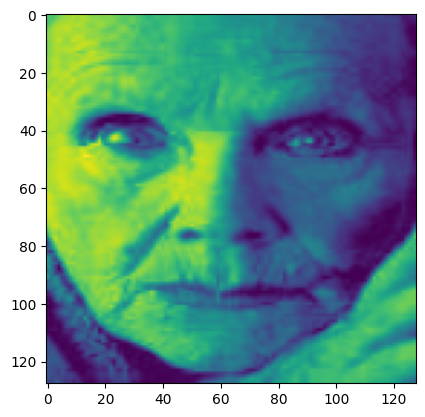

In [ ]:
data_iter = iter(base_train_loader)
image, label = next(data_iter)

plt.imshow(image[0][0])
plt.show()

In [ ]:

if torch.cuda.is_available():
  print("GPU detected")
  device = torch.device("cuda")
else:
  print("No GPU detected")
  device = torch.device("cpu")


GPU detected


In [ ]:
criterion = nn.CrossEntropyLoss()
from sklearn.metrics import precision_score, recall_score, f1_score


def get_accuracy_and_loss(model, test_loader, criterion):
  model.eval()
  test_loss = 0
  all_preds = []
  all_targets = []
  with torch.no_grad():
    test_correct = 0
    for data, target in test_loader:
      data, target = data.to(device), target.to(device)
      output = model(data)
      pred = output.argmax(dim=1)
      test_correct += pred.eq(target).sum().item()
      loss = criterion(output, target)
      test_loss += loss.item()
      all_preds.extend(pred.cpu().numpy())
      all_targets.extend(target.cpu().numpy())
    precision = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
  return test_correct / len(test_loader.dataset), test_loss / len(test_loader.dataset), precision, recall, f1


In [ ]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)


In [ ]:
#Baseline 1 — IEEE Facial Emotion Recognition by Ensemble-DenseNet Networks as a CNN
#Architecture published in https://ieeexplore.ieee.org/document/10461880/authors#authors
#using a CNN instead of densenets as our base, rest of architecture from paper above
import torch.nn as nn

class basemodel(nn.Module):
    def __init__(self, input_size, classes):
        super().__init__()
        self.conv1 = nn.Conv2d(input_size, 32, kernel_size =3)
        self.batch1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size =3)
        self.batch2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2,2)
        self.dropout1 = nn.Dropout(0.2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size =3)
        self.batch3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size =3)
        self.batch4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2,2)
        self.dropout2 = nn.Dropout(0.2)

        self.conv5 = nn.Conv2d(64, 128, kernel_size =3)
        self.batch5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 256, kernel_size =3)
        self.batch6 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2,2)
        self.dropout3 = nn.Dropout(0.2)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.batch7 = nn.BatchNorm1d(256)
        self.dropout4 = nn.Dropout(0.2)
        self.dense1 = nn.Linear(256, 256)

        self.batch8 = nn.BatchNorm1d(256)
        self.dropout5 = nn.Dropout(0.2)
        self.dense2 = nn.Linear(256, 128)

        self.batch9 = nn.BatchNorm1d(128)
        self.dropout6 = nn.Dropout(0.2)
        self.dense3 = nn.Linear(128, 64)

        self.batch10 = nn.BatchNorm1d(64)
        self.dropout7 = nn.Dropout(0.2)
        self.dense4 = nn.Linear(64, classes)



    def forward(self, x):
      x = self.conv1(x)
      x = self.batch1(x)
      x = self.conv2(x)
      x = self.batch2(x)
      x = self.pool1(x)
      x = self.dropout1(x)

      x = self.conv3(x)
      x = self.batch3(x)
      x = self.conv4(x)
      x = self.batch4(x)
      x = self.pool2(x)
      x = self.dropout2(x)

      x = self.conv5(x)
      x = self.batch5(x)
      x = self.conv6(x)
      x = self.batch6(x)
      x = self.pool3(x)
      x = self.dropout3(x)


      x = self.gap(x)
      x = self.flatten(x)
      x =  self.batch7(x)
      x =  self.dropout4(x)
      x =  F.relu(self.dense1(x))

      x=  self.batch8(x)
      x= self.dropout5(x)
      x=  F.relu(self.dense2(x))

      x=  self.batch9(x)
      x =  self.dropout6(x)
      x=  F.relu(self.dense3(x))

      x=  self.batch10(x)
      x=  self.dropout7(x)
      x=  self.dense4(x)

      return x

cnnmodel = basemodel(3, len(categories))
cnnmodel = cnnmodel.to(device)
optimizer = optim.Adam(cnnmodel.parameters(), lr=0.0001, weight_decay=1e-4)
print(cnnmodel)

basemodel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (batch1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (batch2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.2, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (batch3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (batch4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.2, inplace=False)
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (batch5): BatchNorm2d(128, eps=1e-05, momentum=0.1, af

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
epochs_without_improve = 0
criterion = nn.CrossEntropyLoss()
patience = 20

for epoch in range(100):
    cnnmodel.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in base_train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = cnnmodel(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    val_accuracy, val_loss, val_precision, val_recall, val_f1 = get_accuracy_and_loss(cnnmodel, base_test_loader, criterion)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")
    val_losses.append(val_loss)
    # Check for improvement
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(cnnmodel.state_dict(), 'best_cnnmodel.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.26265178062097627
Train loss: 0.06130557837030452
Val accuracy: 0.37540754541220306
Val loss: 0.05496525292514256
Epoch 1 done.
Train accuracy: 0.32197864884687477
Train loss: 0.058284812699844
Val accuracy: 0.3907778295295761
Val loss: 0.0540933520726176
Epoch 2 done.
Train accuracy: 0.34952326623747043
Train loss: 0.05629877322907845
Val accuracy: 0.3879832324173265
Val loss: 0.05367787482852874
Epoch 3 done.
Train accuracy: 0.3656588705077011
Train loss: 0.05459080372139582
Val accuracy: 0.39496972519795065
Val loss: 0.05294030330100057
Epoch 4 done.
Train accuracy: 0.3750305598565724
Train loss: 0.053459597764704166
Val accuracy: 0.38844899860270143
Val loss: 0.055140540218930716
Epoch 5 done.
Train accuracy: 0.38391329150028525
Train loss: 0.052175487538206285
Val accuracy: 0.38844899860270143
Val loss: 0.054952173161961944
Epoch 6 done.
Train accuracy: 0.39181810773368103
Train loss: 0.050824567222641844
Val accuracy: 0.3907778295295761
Val loss: 0

In [ ]:
cnnmodel.eval()
correct = 0
with torch.no_grad():
    for data, target in base_test_loader:
        data, target = data.to(device), target.to(device)
        output = cnnmodel(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
val_accuracy, val_loss, val_precision, val_recall, val_f1 = get_accuracy_and_loss(cnnmodel, base_test_loader, criterion)
print(f"Accuracy: {val_accuracy:.4f} | Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f}")


Accuracy: 0.6595 | Precision: 0.6585 | Recall: 0.6595 | F1: 0.6532


# MediaPipe Implementation

In [ ]:
!pip install -q mediapipe
!wget -O face_landmarker_v2_with_blendshapes.task -q https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

In [ ]:
#Code from https://colab.research.google.com/github/googlesamples/mediapipe/blob/main/examples/face_landmarker/python/%5BMediaPipe_Python_Tasks%5D_Face_Landmarker.ipynb#scrollTo=_JVO3rvPD4RN


import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
import numpy as np
import matplotlib.pyplot as plt


def draw_landmarks_on_image(rgb_image, detection_result):
  face_landmarks_list = detection_result.face_landmarks
  annotated_image = np.copy(rgb_image)

  # Loop through the detected faces to visualize.
  for idx in range(len(face_landmarks_list)):
    face_landmarks = face_landmarks_list[idx]

    # Draw the face landmarks.


    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION,
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_tesselation_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS,
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_contours_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_IRIS,
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_IRIS,
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())

  return annotated_image

def plot_face_blendshapes_bar_graph(face_blendshapes):
  face_blendshapes_names = [face_blendshapes_category.category_name for face_blendshapes_category in face_blendshapes]
  face_blendshapes_scores = [face_blendshapes_category.score for face_blendshapes_category in face_blendshapes]
  face_blendshapes_ranks = range(len(face_blendshapes_names))

  fig, ax = plt.subplots(figsize=(12, 12))
  bar = ax.barh(face_blendshapes_ranks, face_blendshapes_scores, label=[str(x) for x in face_blendshapes_ranks])
  ax.set_yticks(face_blendshapes_ranks, face_blendshapes_names)
  ax.invert_yaxis()

  # Label each bar with values
  for score, patch in zip(face_blendshapes_scores, bar.patches):
    plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

  ax.set_xlabel('Score')
  ax.set_title("Face Blendshapes")
  plt.tight_layout()
  plt.show()

In [ ]:
#Code from https://colab.research.google.com/github/googlesamples/mediapipe/blob/main/examples/face_landmarker/python/%5BMediaPipe_Python_Tasks%5D_Face_Landmarker.ipynb#scrollTo=_JVO3rvPD4RN, adapted with the help of Claude for multiple inputs, specifically Step 3
X_train_landmarks = []
y_train_landmarks = []


# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an FaceLandmarker object.
base_options = python.BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)

# STEP 3: Load the input image.
for img, label in zip(X_train, y_train):
    img_uint8 = (img * 255).astype(np.uint8)  # undo normalization
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_uint8)


# STEP 4: Detect face landmarks from the input image.
    detection_result = detector.detect(mp_image)

# STEP 5: Process the detection result. In this case, visualize it.
    if detection_result.face_landmarks:
        landmarks = detection_result.face_landmarks[0]
        flat = np.array([[lm.x, lm.y, lm.z] for lm in landmarks]).flatten()
        X_train_landmarks.append(flat)
        y_train_landmarks.append(label)

X_train_landmarks = np.array(X_train_landmarks)
y_train_landmarks = np.array(y_train_landmarks)

In [ ]:
X_test_landmarks = []
y_test_landmarks = []

for img, label in zip(X_test, y_test):
    img_uint8 = (img * 255).astype(np.uint8)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_uint8)
    detection_result = detector.detect(mp_image)

    if detection_result.face_landmarks:
        landmarks = detection_result.face_landmarks[0]
        flat = np.array([[lm.x, lm.y, lm.z] for lm in landmarks]).flatten()
        X_test_landmarks.append(flat)
        y_test_landmarks.append(label)

X_test_landmarks = np.array(X_test_landmarks)
y_test_landmarks = np.array(y_test_landmarks)

print(f"Train shape: {X_train_landmarks.shape}")
print(f"Test shape: {X_test_landmarks.shape}")

Train shape: (9856, 1434)
Test shape: (1729, 1434)


In [ ]:
from torch.utils.data import Dataset, DataLoader

class LandmarkDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = LandmarkDataset(X_train_landmarks, y_train_landmarks)
test_dataset  = LandmarkDataset(X_test_landmarks, y_test_landmarks)

lm_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
lm_test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

In [ ]:
#Code from https://colab.research.google.com/github/googlesamples/mediapipe/blob/main/examples/face_landmarker/python/%5BMediaPipe_Python_Tasks%5D_Face_Landmarker.ipynb#scrollTo=_JVO3rvPD4RN

X_train_blendshapes = []
y_train_clean = []
X_test_blendshapes = []
y_test_clean = []

for img, label in zip(X_train, y_train):
    img_uint8 = (img * 255).astype(np.uint8)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_uint8)
    detection_result = detector.detect(mp_image)

    if detection_result.face_blendshapes:
        blendshapes = detection_result.face_blendshapes[0]
        scores = np.array([bs.score for bs in blendshapes])
        X_train_blendshapes.append(scores)
        y_train_clean.append(label)

for img, label in zip(X_test, y_test):
    img_uint8 = (img * 255).astype(np.uint8)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_uint8)
    detection_result = detector.detect(mp_image)

    if detection_result.face_blendshapes:
        blendshapes = detection_result.face_blendshapes[0]
        scores = np.array([bs.score for bs in blendshapes])
        X_test_blendshapes.append(scores)
        y_test_clean.append(label)

X_train_blendshapes = np.array(X_train_blendshapes)
y_train_clean = np.array(y_train_clean)

X_test_blendshapes = np.array(X_test_blendshapes)
y_test_clean = np.array(y_test_clean)

print(f"Shape: {X_train_blendshapes.shape}")
print(f"Dropped {len(X_train) - len(X_train_blendshapes)} images with no face detected")

print(f"Shape: {X_test_blendshapes.shape}")
print(f"Dropped {len(X_test) - len(X_test_blendshapes)} images with no face detected")

Shape: (9856, 52)
Dropped 2415 images with no face detected
Shape: (1729, 52)
Dropped 418 images with no face detected


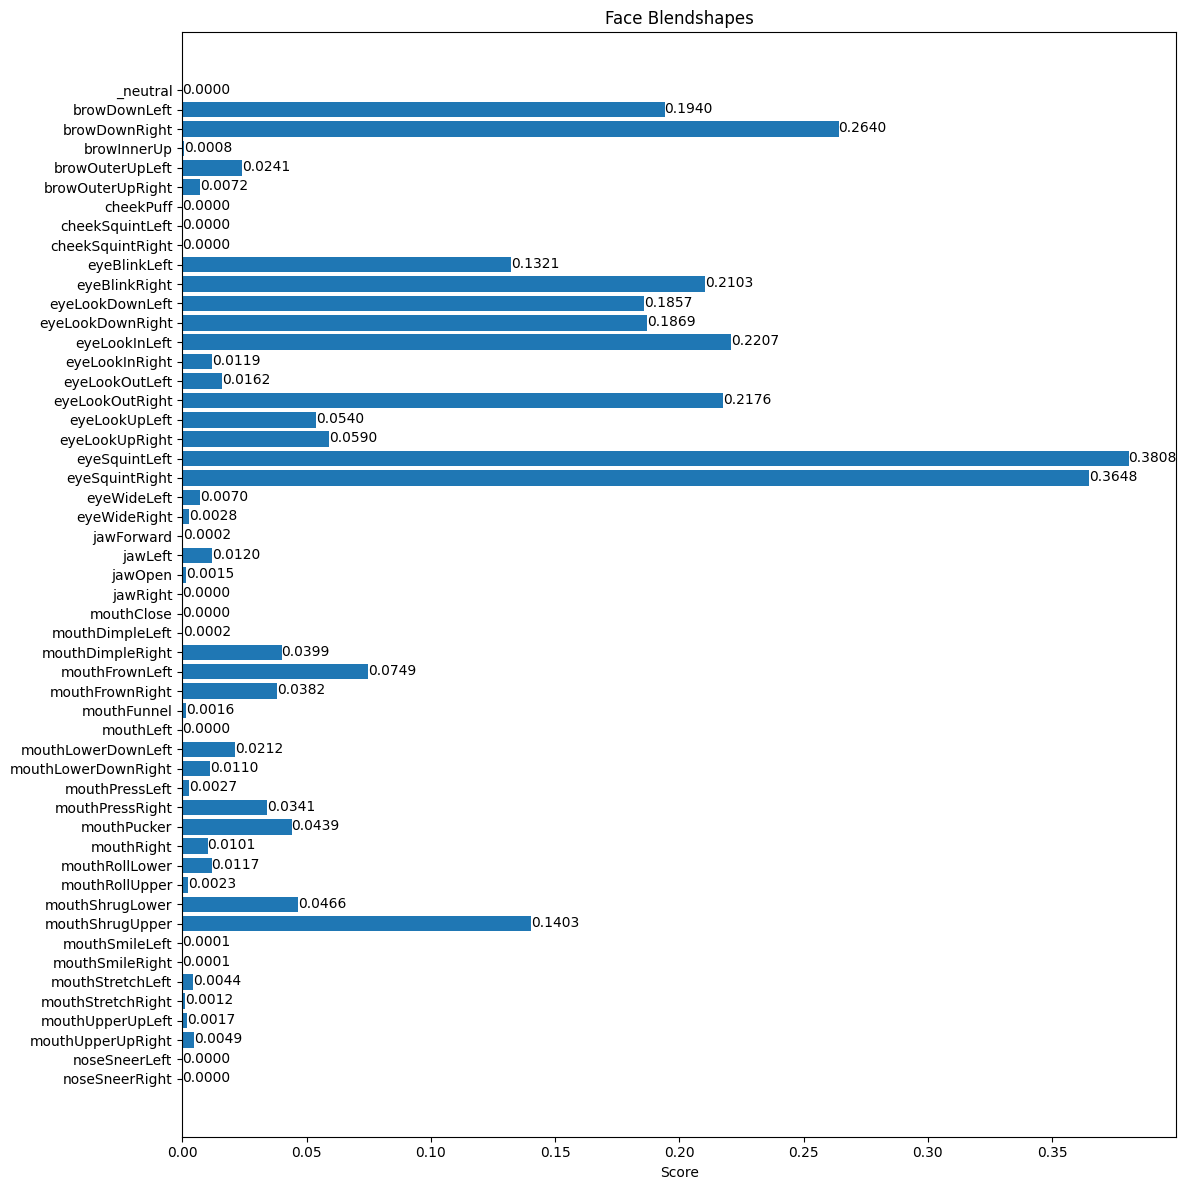

In [ ]:
#Test for MediaPipe Debugging
for img, label in zip(X_train, y_train):
    img_uint8 = (img * 255).astype(np.uint8)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_uint8)
    detection_result = detector.detect(mp_image)

    if detection_result.face_blendshapes:
        plot_face_blendshapes_bar_graph(detection_result.face_blendshapes[0])
        break

In [ ]:
import torch

class BlendshapeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = BlendshapeDataset(X_train_blendshapes, y_train_clean)
test_dataset  = BlendshapeDataset(X_test_blendshapes, y_test_clean)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

In [ ]:
print(X_train_blendshapes.shape)
print(next(iter(train_dataset))[0].shape)

(9856, 52)
torch.Size([52])


In [ ]:
input_size = X_train_blendshapes.shape[1]
input_size

52

##Google ViT

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from transformers import ViTModel
from sklearn.metrics import precision_score, recall_score, f1_score

try:
    from torch_optimizer import RAdam
except ImportError:
    from torch.optim import RAdam   # available natively in PyTorch >= 1.10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
#Debugging using Claude

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

vit_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),  # ← ViT needs 224x224!
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

class ViTDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]  # numpy array (128, 128, 3)
        if self.transform:
            img = self.transform(img)
        return img, self.y[idx]

vit_train_dataset = ViTDataset(X_train, y_train, transform=vit_transform)
vit_test_dataset  = ViTDataset(X_test,  y_test,  transform=vit_transform)

vit_train_loader = DataLoader(vit_train_dataset, batch_size=32, shuffle=True)
vit_test_loader  = DataLoader(vit_test_dataset,  batch_size=32, shuffle=False)

In [ ]:
NUM_CLASSES = 7
from torch.optim import RAdam


class GoogleViTEmotionClassifier(nn.Module):
    """
    Google ViT-B/16 (ImageNet-21k) backbone with a two-layer
    Dense + BatchNorm head for 7-class emotion recognition.
    """
    def __init__(self, num_classes: int = 7, freeze_backbone: bool = True):
        super().__init__()

        # Official Google ViT-B/16 weights pretrained on ImageNet-21k
        self.backbone = ViTModel.from_pretrained("google/vit-base-patch16-224")

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        hidden = self.backbone.config.hidden_size  # 768 for ViT-B/16

        # Two Dense + BatchNorm layers, 7-class output (Bousaid & Hajji)
        self.head = nn.Sequential(
            nn.Linear(hidden, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, num_classes),
            nn.BatchNorm1d(num_classes),
        )
        # Softmax is handled by CrossEntropyLoss during training.
        # Call predict_proba() to get explicit probabilities at inference.

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        outputs  = self.backbone(pixel_values=pixel_values)
        cls_token = outputs.last_hidden_state[:, 0, :]  # [CLS] token (B, 768)
        return self.head(cls_token)                      # (B, num_classes)

    def predict_proba(self, pixel_values: torch.Tensor) -> torch.Tensor:
        return F.softmax(self.forward(pixel_values), dim=-1)


vitmodel = GoogleViTEmotionClassifier(num_classes=NUM_CLASSES, freeze_backbone=True)
vitmodel = vitmodel.to(device)

total_params     = sum(p.numel() for p in vitmodel.parameters())
trainable_params = sum(p.numel() for p in vitmodel.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"\nParameter summary:")
print(f"  Total params     : {total_params:,}")
print(f"  Frozen params    : {frozen_params:,}  <- Google ViT-B/16 backbone")
print(f"  Trainable params : {trainable_params:,}  <- 7-class emotion head")

# Sanity check
vitmodel.eval()
with torch.no_grad():
    dummy  = torch.randn(4, 3, 224, 224).to(device)
    output = vitmodel(dummy)
    print(f"\nOutput shape check:")
    print(f"  Input  : {dummy.shape}")
    print(f"  Output : {output.shape}")  # (4, 7)

# ── Training ───────────────────────────────────────────────────────────────

criterion = nn.CrossEntropyLoss()
optimizer = RAdam(
    filter(lambda p: p.requires_grad, vitmodel.parameters()),
    lr=1e-3,
)



NUM_EPOCHS       = 100
best_val_loss    = float('inf')
patience         = 3
patience_counter = 0
train_losses     = []
train_accuracies = []
val_accuracies = []
val_losses       = []

print(f"\nStarting training for {NUM_EPOCHS} epochs...")
print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'F1':<8}")
print("-" * 62)

for epoch in range(NUM_EPOCHS):
    vitmodel.train()
    train_loss    = 0
    train_correct = 0

    for images, labels in vit_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vitmodel(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item()
        train_correct += outputs.argmax(dim=1).eq(labels).sum().item()

    train_loss = train_loss / len(vit_train_loader)
    train_acc  = train_correct / len(vit_train_loader.dataset)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_accuracy, val_loss, val_precision, val_recall, val_f1 = get_accuracy_and_loss(vitmodel, vit_test_loader, criterion)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"{epoch+1:<6} {train_loss:<12.4f} {train_acc:<12.4f} {val_loss:<12.4f} {val_accuracy:<12.4f} {val_f1:<8.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(vitmodel.state_dict(), 'best_google_vit_rafdb.pth')
        print(f"Best model saved")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("\nTraining complete.")
print(f"Best val loss: {best_val_loss:.4f}")

vitmodel.load_state_dict(torch.load('best_google_vit_rafdb.pth'))
vit_val_accuracy, vit_val_loss, vit_val_precision, vit_val_recall, vit_val_f1 = get_accuracy_and_loss(vitmodel, vit_test_loader, criterion)

print(f"\nFinal metrics on validation set:")
print(f"  Accuracy  : {vit_val_accuracy:.4f}")
print(f"  Precision : {vit_val_precision:.4f}")
print(f"  Recall    : {vit_val_recall:.4f}")
print(f"  F1        : {vit_val_f1:.4f}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Parameter summary:
  Total params     : 86,787,605
  Frozen params    : 86,389,248  <- Google ViT-B/16 backbone
  Trainable params : 398,357  <- 7-class emotion head

Output shape check:
  Input  : torch.Size([4, 3, 224, 224])
  Output : torch.Size([4, 7])

Starting training for 100 epochs...
Epoch  Train Loss   Train Acc    Val Loss     Val Acc      F1      
--------------------------------------------------------------
1      1.3583       0.5577       0.0366       0.6507       0.6585  
Best model saved
2      1.0778       0.6711       0.0330       0.6684       0.6692  
Best model saved
3      0.9347       0.7164       0.0314       0.6721       0.6716  
Best model saved
4      0.8365       0.7376       0.0311       0.6702       0.6682  
Best model saved
5      0.7563       0.7561       0.0297       0.6856       0.6844  
Best model saved
6      0.6713       0.7823       0.0297       0.6810       0.6758  
Best model saved
7      0.5954       0.8097       0.0287       0.6833       0.676

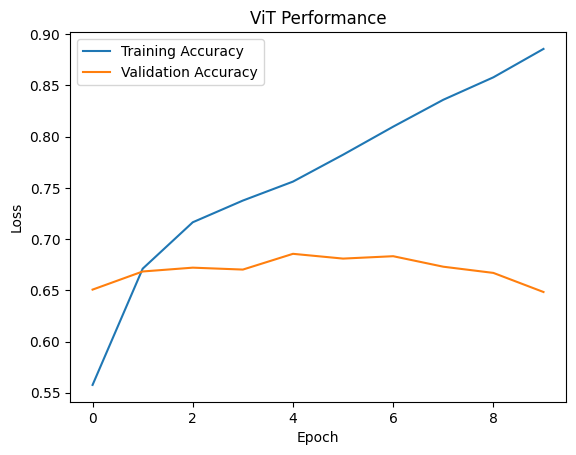

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('ViT Performance')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
#Architecture 1 — IEEE Facial Emotion Recognition by Ensemble-DenseNet Networks, with MediaPipe Implementation
#Layer architecture published in https://ieeexplore.ieee.org/document/10461880/authors#authors
#Difference: Used mediapipe output as an input instead of DenseNet as a basemodel
import torch.nn as nn

class emotionNN(nn.Module):
    def __init__(self, input_size, classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.batch = nn.BatchNorm1d(input_size)
        self.dropout = nn.Dropout(0.2)
        self.dense = nn.Linear(input_size, 256)

        self.batch2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.2)
        self.dense2 = nn.Linear(256, 128)

        self.batch3 = nn.BatchNorm1d(128)
        self.dropout3 = nn.Dropout(0.2)
        self.dense3 = nn.Linear(128,64)


        self.batch4 = nn.BatchNorm1d(64)
        self.dropout4 = nn.Dropout(0.2)
        self.dense4 = nn.Linear(64, classes)



    def forward(self, x):
      x = self.flatten(x)
      x = self.batch(x)
      x = self.dropout(x)
      x = F.relu(self.dense(x))
      x = self.batch2(x)
      x = self.dropout2(x)
      x = F.relu(self.dense2(x))
      x = self.batch3(x)
      x = self.dropout3(x)
      x = F.relu(self.dense3(x))
      x = self.batch4(x)
      x = self.dropout4(x)
      x = self.dense4(x)

      return x

model1 = emotionNN(input_size, len(categories))
model1 = model1.to(device)
optimizer = optim.Adam(model1.parameters(), lr=0.0001, weight_decay=1e-4)
print(model1)

emotionNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (batch): BatchNorm1d(52, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (dense): Linear(in_features=52, out_features=256, bias=True)
  (batch2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (dense2): Linear(in_features=256, out_features=128, bias=True)
  (batch3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (dense3): Linear(in_features=128, out_features=64, bias=True)
  (batch4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout4): Dropout(p=0.2, inplace=False)
  (dense4): Linear(in_features=64, out_features=7, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
val_losses = []
train_losses = []
val_accuracies = []
train_accuracies = []
patience = 20
best_val_loss = float('inf')
epochs_since_best = 0
for epoch in range(100):
    model1.train()
    train_loss = 0
    train_correct = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        output = model1(data)
        pred = output.argmax(dim=1)
        train_correct += pred.eq(target).sum().item()
        optimizer.zero_grad()
        loss = criterion(output, target)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} done.")
    print(f"Train accuracy: {train_correct / len(train_loader.dataset):.4f}")
    print(f"Train loss: {train_loss}")
    train_losses += [train_loss]
    train_accuracies.append(train_correct / len(train_loader.dataset))
    val_accuracy, val_loss, val_precision, val_recall, val_f1  = get_accuracy_and_loss(model1, test_loader, criterion)
    val_accuracies.append(val_accuracy)
    print(f"Val accuracy: {val_accuracy:.4f}")
    print(f"Val loss: {val_loss}")
    val_losses += [val_loss]
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      epochs_since_best = 0
    else:
      epochs_since_best += 1
      if epochs_since_best >= patience:
        print("Early stopping")
        break

Epoch 0 done.
Train accuracy: 0.4171
Train loss: 500.00042366981506
Val accuracy: 0.5894
Val loss: 0.04104894516852772
Epoch 1 done.
Train accuracy: 0.5478
Train loss: 414.6566898226738
Val accuracy: 0.6183
Val loss: 0.03707641173539788
Epoch 2 done.
Train accuracy: 0.5770
Train loss: 387.0522063970566
Val accuracy: 0.6229
Val loss: 0.03590906483372765
Epoch 3 done.
Train accuracy: 0.5835
Train loss: 375.2975465655327
Val accuracy: 0.6316
Val loss: 0.03531421978670852
Epoch 4 done.
Train accuracy: 0.5887
Train loss: 369.2034522294998
Val accuracy: 0.6339
Val loss: 0.03455786728459055
Epoch 5 done.
Train accuracy: 0.5927
Train loss: 364.61261850595474
Val accuracy: 0.6362
Val loss: 0.03419413895466343
Epoch 6 done.
Train accuracy: 0.5976
Train loss: 356.67886942625046
Val accuracy: 0.6431
Val loss: 0.03424216475081347
Epoch 7 done.
Train accuracy: 0.5935
Train loss: 355.9722650051117
Val accuracy: 0.6420
Val loss: 0.0334059127911865
Epoch 8 done.
Train accuracy: 0.5981
Train loss: 349.9

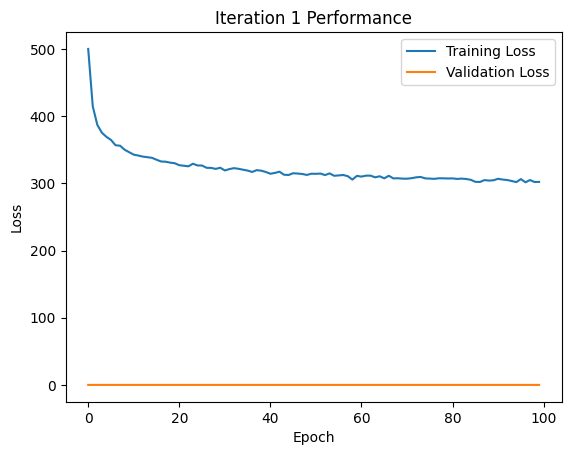

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Iteration 1 Performance')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model1.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model1(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
m1_val_accuracy, m1_val_loss, m1_val_precision, m1_val_recall, m1_val_f1 = get_accuracy_and_loss(model1, test_loader, criterion)
print(f"Accuracy: {m1_val_accuracy:.4f} | Precision: {m1_val_precision:.4f} | Recall: {m1_val_recall:.4f} | F1: {m1_val_f1:.4f}")


Accuracy: 0.6698 | Precision: 0.6554 | Recall: 0.6698 | F1: 0.6418


In [ ]:
#Iteration 2 — Improving on the baseline, added another dense layer

class emotionNN2(nn.Module):
    def __init__(self, input_size, classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.batch = nn.BatchNorm1d(input_size)
        self.dropout = nn.Dropout(0.2)

        self.dense = nn.Linear(input_size, 512)
        self.batch2 = nn.BatchNorm1d(512)
        self.dropout2 = nn.Dropout(0.2)

        self.dense2 = nn.Linear(512, 256)
        self.batch3 = nn.BatchNorm1d(256)
        self.dropout3 = nn.Dropout(0.2)

        self.dense3 = nn.Linear(256,128)
        self.batch4 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(0.2)

        self.dense4 = nn.Linear(128, 64)
        self.batch5 = nn.BatchNorm1d(64)
        self.dropout5 = nn.Dropout(0.2)

        self.dense5 = nn.Linear(64, classes)


    def forward(self, x):
      x = self.flatten(x)
      x = self.batch(x)
      x = self.dropout(x)
      x = F.relu(self.dense(x))
      x = self.batch2(x)
      x = self.dropout2(x)
      x = F.relu(self.dense2(x))
      x = self.batch3(x)
      x = self.dropout3(x)
      x = F.relu(self.dense3(x))
      x = self.batch4(x)
      x = self.dropout4(x)
      x = F.relu(self.dense4(x))
      x = self.batch5(x)
      x = self.dropout5(x)
      x = self.dense5(x)

      return x

model2 = emotionNN2(input_size, len(categories))
model2 = model2.to(device)
optimizer = optim.Adam(model2.parameters(), lr=0.0001, weight_decay=1e-4)
print(model2)

emotionNN2(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (batch): BatchNorm1d(52, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (dense): Linear(in_features=52, out_features=512, bias=True)
  (batch2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (dense2): Linear(in_features=512, out_features=256, bias=True)
  (batch3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (dense3): Linear(in_features=256, out_features=128, bias=True)
  (batch4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout4): Dropout(p=0.2, inplace=False)
  (dense4): Linear(in_features=128, out_features=64, bias=True)
  (batch5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout5): Dropout(p=0.2, inplace=False)
  (d

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
epochs_without_improve = 0
criterion = nn.CrossEntropyLoss()
patience = 20

for epoch in range(100):
    model2.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model2(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    val_accuracy, val_loss, val_precision, val_recall, val_f1 = get_accuracy_and_loss(model2, test_loader, criterion)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")
    val_losses.append(val_loss)
    # Check for improvement
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model2.state_dict(), 'best_model2.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.44044237012987014
Train loss: 0.04907469926764826
Val accuracy: 0.5997686524002314
Val loss: 0.03928244406946688
Epoch 1 done.
Train accuracy: 0.562601461038961
Train loss: 0.04058908758225379
Val accuracy: 0.6234817813765182
Val loss: 0.03655507079847566
Epoch 2 done.
Train accuracy: 0.580560064935065
Train loss: 0.038910464903750976
Val accuracy: 0.6240601503759399
Val loss: 0.03620908389965739
Epoch 3 done.
Train accuracy: 0.5869521103896104
Train loss: 0.037542460891478634
Val accuracy: 0.6350491613649508
Val loss: 0.03489907178112094
Epoch 4 done.
Train accuracy: 0.5916193181818182
Train loss: 0.03711033997113829
Val accuracy: 0.637941006362059
Val loss: 0.033864105382084224
Epoch 5 done.
Train accuracy: 0.601461038961039
Train loss: 0.035910931313047546
Val accuracy: 0.6471949103528051
Val loss: 0.033379581706795544
Epoch 6 done.
Train accuracy: 0.596489448051948
Train loss: 0.03614799294911035
Val accuracy: 0.6483516483516484
Val loss: 0.035045898

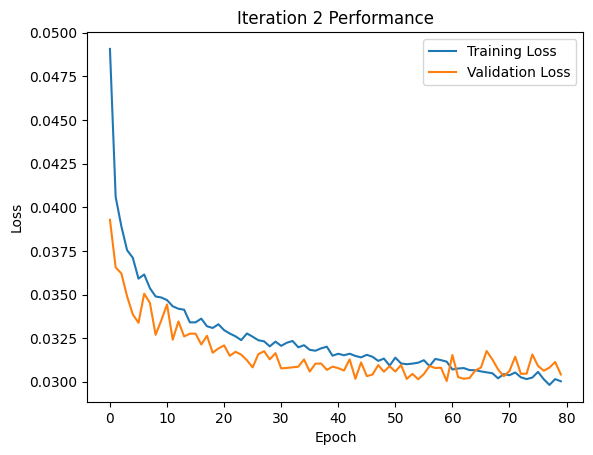

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Iteration 2 Performance')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model2.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model2(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
m2_val_accuracy, m2_val_loss, m2_val_precision, m2_val_recall, m2_val_f1 = get_accuracy_and_loss(model2, test_loader, criterion)
print(f"Accuracy: {m2_val_accuracy:.4f} | Precision: {m2_val_precision:.4f} | Recall: {m2_val_recall:.4f} | F1: {m2_val_f1:.4f}")


Accuracy: 0.6605 | Precision: 0.6486 | Recall: 0.6605 | F1: 0.6372


In [ ]:
#Iteration 3 - Added residual connection
#Used AI to help understand how to implement residual connections

class emotionNN3(nn.Module):
    def __init__(self, input_size, classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.batch1 = nn.BatchNorm1d(input_size)
        self.dropout1 = nn.Dropout(0.2)

        self.dense1 = nn.Linear(input_size, 256)
        self.batch2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.3)

        self.dense2 = nn.Linear(256, 256)
        self.batch3 = nn.BatchNorm1d(256)
        self.dropout3 = nn.Dropout(0.3)

        self.dense3 = nn.Linear(256, 128)
        self.batch4 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(0.3)

        self.dense4 = nn.Linear(128, 64)
        self.batch5 = nn.BatchNorm1d(64)
        self.dropout5 = nn.Dropout(0.2)

        self.dense5 = nn.Linear(64, classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout1(self.batch1(x))

        x = F.relu(self.dense1(x))
        x = self.batch2(x)
        x = self.dropout2(x)

        residual = x
        x = F.relu(self.dense2(x))
        x = self.batch3(x)
        x = x + residual
        x = self.dropout3(x)

        x = F.relu(self.dense3(x))
        x = self.batch4(x)
        x = self.dropout4(x)

        x = F.relu(self.dense4(x))
        x = self.batch5(x)
        x = self.dropout5(x)

        x = self.dense5(x)
        return x

model3 = emotionNN3(input_size, len(categories))
model3 = model3.to(device)
optimizer = optim.Adam(model3.parameters(), lr=0.0001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
epochs_without_improve = 0
criterion = nn.CrossEntropyLoss()
patience = 20

for epoch in range(200):
    model3.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model3(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    val_accuracy, val_loss, val_precision, val_recall, val_f1 = get_accuracy_and_loss(model3, test_loader, criterion)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")
    val_losses.append(val_loss)
    # Check for improvement
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model3.state_dict(), 'best_model3.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.39620535714285715
Train loss: 0.05239645349369808
Val accuracy: 0.6032388663967612
Val loss: 0.04273782764438124
Epoch 1 done.
Train accuracy: 0.5281047077922078
Train loss: 0.04383905716966112
Val accuracy: 0.6217466743782534
Val loss: 0.039157716851485405
Epoch 2 done.
Train accuracy: 0.557224025974026
Train loss: 0.04117474328218536
Val accuracy: 0.6223250433776749
Val loss: 0.03743752108067015
Epoch 3 done.
Train accuracy: 0.5736607142857143
Train loss: 0.03936901831297905
Val accuracy: 0.6304222093695778
Val loss: 0.036857002004851765
Epoch 4 done.
Train accuracy: 0.5748782467532467
Train loss: 0.038920803049990495
Val accuracy: 0.6338924233661076
Val loss: 0.03561448978509015
Epoch 5 done.
Train accuracy: 0.5827922077922078
Train loss: 0.03791767159815539
Val accuracy: 0.6310005783689995
Val loss: 0.03558943315073546
Epoch 6 done.
Train accuracy: 0.5814732142857143
Train loss: 0.037618031404767334
Val accuracy: 0.6263736263736264
Val loss: 0.034829

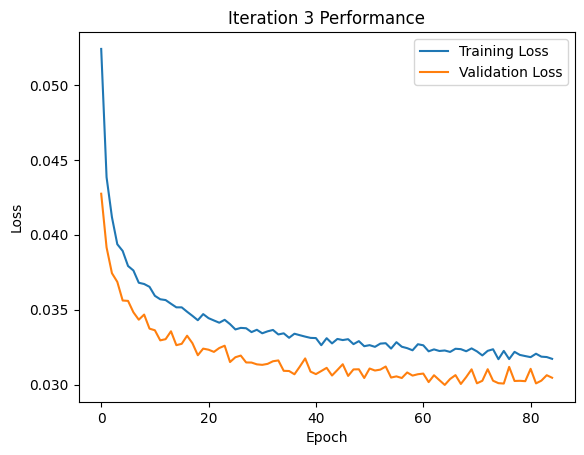

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Iteration 3 Performance')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model3.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model3(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
m3_val_accuracy, m3_val_loss, m3_val_precision, m3_val_recall, m3_val_f1 = get_accuracy_and_loss(model3, test_loader, criterion)
print(f"Accuracy: {m3_val_accuracy:.4f} | Precision: {m3_val_precision:.4f} | Recall: {m3_val_recall:.4f} | F1: {m3_val_f1:.4f}")


Accuracy: 0.6703 | Precision: 0.6607 | Recall: 0.6703 | F1: 0.6403


In [ ]:
#Iteration 4 -Added wider first layer

class emotionNN4(nn.Module):
    def __init__(self, input_size, classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.batch1 = nn.BatchNorm1d(input_size)
        self.dropout1 = nn.Dropout(0.2)

        self.dense1 = nn.Linear(input_size, 512)
        self.batch2 = nn.BatchNorm1d(512)
        self.dropout2 = nn.Dropout(0.3)

        self.dense2 = nn.Linear(512, 512)
        self.batch3 = nn.BatchNorm1d(512)
        self.dropout3 = nn.Dropout(0.3)

        self.dense3 = nn.Linear(512, 128)
        self.batch4 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(0.3)

        self.dense4 = nn.Linear(128, 64)
        self.batch5 = nn.BatchNorm1d(64)
        self.dropout5 = nn.Dropout(0.2)

        self.dense5 = nn.Linear(64, classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout1(self.batch1(x))

        x = F.relu(self.dense1(x))
        x = self.batch2(x)
        x = self.dropout2(x)

        residual = x
        x = F.relu(self.dense2(x))
        x = self.batch3(x)
        x = x + residual
        x = self.dropout3(x)

        x = F.relu(self.dense3(x))
        x = self.batch4(x)
        x = self.dropout4(x)

        x = F.relu(self.dense4(x))
        x = self.batch5(x)
        x = self.dropout5(x)

        x = self.dense5(x)
        return x

model4 = emotionNN4(input_size, len(categories))
model4 = model4.to(device)
optimizer = optim.Adam(model4.parameters(), lr=0.0001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
epochs_without_improve = 0
criterion = nn.CrossEntropyLoss()
patience = 20

for epoch in range(200):
    model4.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model4(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    val_accuracy, val_loss, val_precision, val_recall, val_f1 = get_accuracy_and_loss(model4, test_loader, criterion)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")
    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model4.state_dict(), 'best_model4.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.43344155844155846
Train loss: 0.049427514811131085
Val accuracy: 0.6026604973973395
Val loss: 0.040181911701822365
Epoch 1 done.
Train accuracy: 0.5618912337662337
Train loss: 0.040809889027679506
Val accuracy: 0.6171197223828803
Val loss: 0.03753146079318795
Epoch 2 done.
Train accuracy: 0.5697037337662337
Train loss: 0.039215170451766486
Val accuracy: 0.6275303643724697
Val loss: 0.035919321831283435
Epoch 3 done.
Train accuracy: 0.5748782467532467
Train loss: 0.03830604786779006
Val accuracy: 0.631578947368421
Val loss: 0.03552984639769555
Epoch 4 done.
Train accuracy: 0.5866477272727273
Train loss: 0.03743634509624212
Val accuracy: 0.6286871023713129
Val loss: 0.03465474689537697
Epoch 5 done.
Train accuracy: 0.588575487012987
Train loss: 0.03693855583498424
Val accuracy: 0.6402544823597455
Val loss: 0.03448208695963809
Epoch 6 done.
Train accuracy: 0.5945616883116883
Train loss: 0.03624441169879653
Val accuracy: 0.6402544823597455
Val loss: 0.033867

In [ ]:
model4.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model4(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
m4_val_accuracy, m4_val_loss, m4_val_precision, m4_val_recall, m4_val_f1 = get_accuracy_and_loss(model4, test_loader, criterion)
print(f"Accuracy: {m4_val_accuracy:.4f} | Precision: {m4_val_precision:.4f} | Recall: {m4_val_recall:.4f} | F1: {m4_val_f1:.4f}")


Accuracy: 0.6692 | Precision: 0.6560 | Recall: 0.6692 | F1: 0.6448


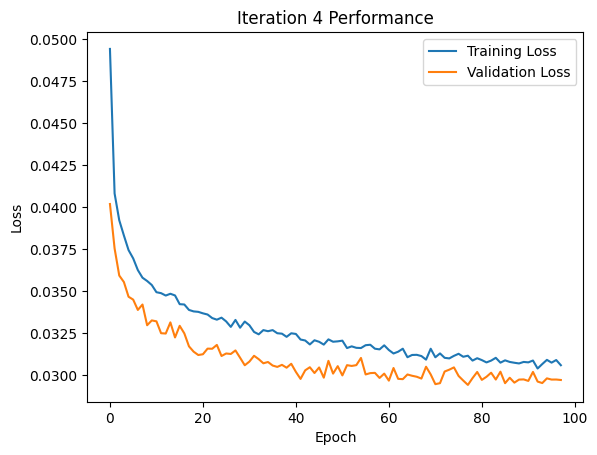

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Iteration 4 Performance')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# @title
#Iteration 5 - Added softmax at the end, did not run properly — leaving for reference

class emotionNN5(nn.Module):
    def __init__(self, input_size, classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.batch1 = nn.BatchNorm1d(input_size)
        self.dropout1 = nn.Dropout(0.2)

        self.dense1 = nn.Linear(input_size, 512)
        self.batch2 = nn.BatchNorm1d(512)
        self.dropout2 = nn.Dropout(0.3)

        self.dense2 = nn.Linear(512, 256)
        self.batch3 = nn.BatchNorm1d(256)
        self.dropout3 = nn.Dropout(0.3)

        self.dense3 = nn.Linear(256, 128)
        self.batch4 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(0.3)

        self.dense4 = nn.Linear(128, 64)
        self.batch5 = nn.BatchNorm1d(64)
        self.dropout5 = nn.Dropout(0.2)

        self.dense5 = nn.Linear(64, classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout1(self.batch1(x))

        x = F.relu(self.dense1(x))
        x = self.batch2(x)
        x = self.dropout2(x)

        residual = x
        x = F.relu(self.dense2(x))
        x = self.batch3(x)
        x = x + residual
        x = self.dropout3(x)

        x = F.relu(self.dense3(x))
        x = self.batch4(x)
        x = self.dropout4(x)

        x = F.relu(self.dense4(x))
        x = self.batch5(x)
        x = self.dropout5(x)

        x = F.softmax(self.dense5(x), dim = 1)
        return x

model5 = emotionNN5(input_size, len(categories))
model5 = model5.to(device)
optimizer = optim.Adam(model5.parameters(), lr=0.0001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [ ]:
# @title
#Model 5 - DO not run

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
epochs_without_improve = 0
criterion = nn.CrossEntropyLoss()
patience = 20

for epoch in range(200):
    model5.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model5(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    val_accuracy, val_loss, val_precision, val_recall, val_f1 = get_accuracy_and_loss(model5, test_loader, criterion)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")
    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model5.state_dict(), 'best_model5.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

RuntimeError: The size of tensor a (256) must match the size of tensor b (512) at non-singleton dimension 1

In [ ]:
# @title
#Model 5 - DO not run

model5.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model5(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
m5_val_accuracy, m5_val_loss, m5_val_precision, m5_val_recall, m5_val_f1 = get_accuracy_and_loss(model5, test_loader, criterion)
print(f"Accuracy: {m5_val_accuracy:.4f} | Precision: {m5_val_precision:.4f} | Recall: {m5_val_recall:.4f} | F1: {m5_val_f1:.4f}")


RuntimeError: The size of tensor a (256) must match the size of tensor b (512) at non-singleton dimension 1

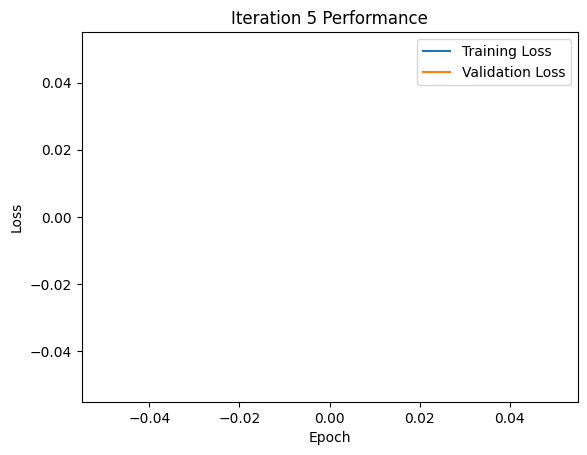

In [ ]:
# @title
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Iteration 5 Performance')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
#Iteration 6 - Testing different patience on best performing model so far, used Claude for debugging and syntax help

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

criterion = nn.CrossEntropyLoss()
patiences = [1, 3, 5, 7, 9, 15, 20]
best_patience_f1 = 0
bestpat = 0

m6_accuracy = 0
m6_loss = 0
m6_precision = 0
m6_recall = 0

for patience in patiences:
  print(patience)
  model6 = emotionNN4(input_size, len(categories)).to(device)
  optimizer = optim.Adam(model6.parameters(), lr=0.0001, weight_decay=1e-4)
  best_val_loss = float('inf')
  epochs_without_improve = 0
  for epoch in range(200):
      model6.train()
      for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model6(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
      val_accuracy, val_loss, val_precision, val_recall, val_f1 = get_accuracy_and_loss(model6, test_loader, criterion)
      if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model6.state_dict(), f'best_model6_patience{patience}.pth')
        epochs_without_improve = 0
      else:
        epochs_without_improve += 1
        if epochs_without_improve >= patience:
          break
  model6.load_state_dict(torch.load(f'best_model6_patience{patience}.pth'))

  acc, loss, prec, rec, f1 = get_accuracy_and_loss(model6, test_loader, criterion)
  print(f"Patience {patience} → F1: {f1:.4f}")

  if f1 > best_patience_f1:
      best_patience_f1 = f1
      best_patience = patience
      m6_accuracy = acc
      m6_loss = loss
      m6_precision = prec
      m6_recall = rec

print(f"Best Patience: {best_patience} | Accuracy: {m6_accuracy:.4f} | Precision: {m6_precision:.4f} | Recall: {m6_recall:.4f} | F1: {best_patience_f1:.4f}")

1
Patience 1 → F1: 0.5836
3
Patience 3 → F1: 0.5933
5
Patience 5 → F1: 0.6420
7
Patience 7 → F1: 0.6260
9
Patience 9 → F1: 0.6425
15
Patience 15 → F1: 0.6359
20
Patience 20 → F1: 0.6463
Best Patience: 20 | Accuracy: 0.6715 | Precision: 0.6563 | Recall: 0.6715 | F1: 0.6463


In [ ]:
model6.load_state_dict(torch.load(f'best_model6_patience{best_patience}.pth'))

m6_val_accuracy, m6_val_loss, m6_val_precision, m6_val_recall, m6_val_f1 = get_accuracy_and_loss(model6, test_loader, criterion)
print(f"Best patience: {best_patience}")
print(f"Accuracy: {m6_val_accuracy:.4f} | Precision: {m6_val_precision:.4f} | Recall: {m6_val_recall:.4f} | F1: {m6_val_f1:.4f}")

Best patience: 20
Accuracy: 0.6715 | Precision: 0.6563 | Recall: 0.6715 | F1: 0.6463


In [ ]:
#Iteration 7 -- Putting it all together

class emotionNN8(nn.Module):
    def __init__(self, input_size, classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.batch1 = nn.BatchNorm1d(input_size)
        self.dropout1 = nn.Dropout(0.2)

        self.dense1 = nn.Linear(input_size, 512)
        self.batch2 = nn.BatchNorm1d(512)
        self.dropout2 = nn.Dropout(0.3)

        self.dense2 = nn.Linear(512, 512)
        self.batch3 = nn.BatchNorm1d(512)
        self.dropout3 = nn.Dropout(0.3)

        self.dense3 = nn.Linear(512, 128)
        self.batch4 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(0.3)

        self.dense4 = nn.Linear(128, classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout1(self.batch1(x))

        x = F.relu(self.dense1(x))
        x = self.batch2(x)
        x = self.dropout2(x)

        residual = x
        x = F.relu(self.dense2(x))
        x = self.batch3(x)
        x = x + residual
        x = self.dropout3(x)

        x = F.relu(self.dense3(x))
        x = self.batch4(x)
        x = self.dropout4(x)

        x = self.dense4(x)
        return x

model7 = emotionNN8(input_size, len(categories))
model7 = model7.to(device)
optimizer = optim.Adam(model7.parameters(), lr=0.0001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
epochs_without_improve = 0
criterion = nn.CrossEntropyLoss()
patience = 15

for epoch in range(200):
    model7.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model7(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    val_accuracy, val_loss, val_precision, val_recall, val_f1 = get_accuracy_and_loss(model7, test_loader, criterion)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")
    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model7.state_dict(), 'best_model7.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.47879464285714285
Train loss: 0.04679103194457757
Val accuracy: 0.626951995373048
Val loss: 0.03812509344243259
Epoch 1 done.
Train accuracy: 0.5743709415584416
Train loss: 0.03967763750221242
Val accuracy: 0.633314054366686
Val loss: 0.035878125196802196
Epoch 2 done.
Train accuracy: 0.5804586038961039
Train loss: 0.03806204685651056
Val accuracy: 0.6344707923655292
Val loss: 0.03533214982221966
Epoch 3 done.
Train accuracy: 0.5900974025974026
Train loss: 0.037134023256261244
Val accuracy: 0.6443030653556969
Val loss: 0.035212997413908834
Epoch 4 done.
Train accuracy: 0.5957792207792207
Train loss: 0.0363363683550292
Val accuracy: 0.6408328513591671
Val loss: 0.03424330933925525
Epoch 5 done.
Train accuracy: 0.5985186688311688
Train loss: 0.03597149503864832
Val accuracy: 0.6483516483516484
Val loss: 0.034181874807753816
Epoch 6 done.
Train accuracy: 0.5997362012987013
Train loss: 0.03540832910372259
Val accuracy: 0.6419895893580104
Val loss: 0.03338877

In [ ]:
model7.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model7(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
m7_val_accuracy, m7_val_loss, m7_val_precision, m7_val_recall, m7_val_f1 = get_accuracy_and_loss(model7, test_loader, criterion)
print(f"Accuracy: {m7_val_accuracy:.4f} | Precision: {m7_val_precision:.4f} | Recall: {m7_val_recall:.4f} | F1: {m7_val_f1:.4f}")


Accuracy: 0.6721 | Precision: 0.6569 | Recall: 0.6721 | F1: 0.6402


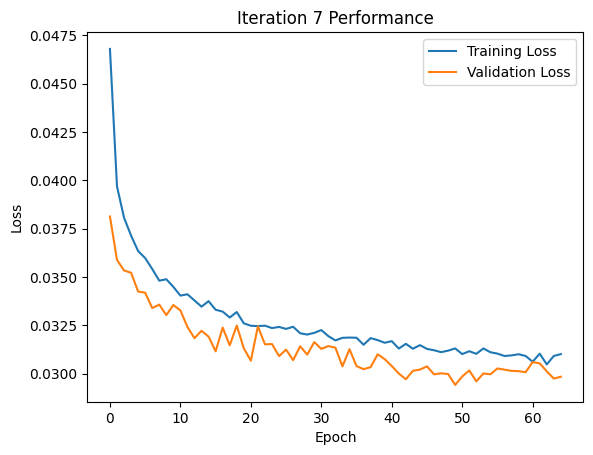

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Iteration 7 Performance')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from tabulate import tabulate

table = [["Model", 'Accuracy', 'Loss', 'Precision', 'Recall', 'F1'],
        ["Google ViT", vit_val_accuracy, vit_val_loss, vit_val_precision, vit_val_recall, vit_val_f1],
        ["CNN",val_accuracy, val_loss, val_precision, val_recall, val_f1],
         ["Iteration 1 -- Baseline for using MediaPipe Inputs", m1_val_accuracy, m1_val_loss, m1_val_precision, m1_val_recall, m1_val_f1],
          ["Iteration 2 -- Added another dense layer", m2_val_accuracy, m2_val_loss, m2_val_precision, m2_val_recall, m2_val_f1],
         ["Iteration 3 -- Added residual connection", m3_val_accuracy, m3_val_loss, m3_val_precision, m3_val_recall, m3_val_f1],
         ["Iteration 4 -- Added wider first layer", m4_val_accuracy, m4_val_loss, m4_val_precision, m4_val_recall, m4_val_f1],
           ["Iteration 6 -- Patience Tuning", m6_val_accuracy, m6_val_loss, m6_val_precision, m6_val_recall, m6_val_f1],
         ["Iteration 7 -- Putting it all together", m7_val_accuracy, m7_val_loss, m7_val_precision, m7_val_recall, m7_val_f1] ]
print(tabulate(table, headers="firstrow", floatfmt=".4f", tablefmt="grid"))



+----------------------------------------------------+------------+--------+-------------+----------+--------+
| Model                                              |   Accuracy |   Loss |   Precision |   Recall |     F1 |
+====================================================+============+========+=============+==========+========+
| Google ViT                                         |     0.6833 | 0.0287 |      0.6791 |   0.6833 | 0.6763 |
+----------------------------------------------------+------------+--------+-------------+----------+--------+
| CNN                                                |     0.6721 | 0.0298 |      0.6569 |   0.6721 | 0.6402 |
+----------------------------------------------------+------------+--------+-------------+----------+--------+
| Iteration 1 -- Baseline for using MediaPipe Inputs |     0.6698 | 0.0312 |      0.6554 |   0.6698 | 0.6418 |
+----------------------------------------------------+------------+--------+-------------+----------+--------+
|

##Ensemble Network

In [ ]:
X_final_blendshapes = []
y_final_clean = []
final_mediapipe_indices = []

for i, (img, label) in enumerate(zip(X_final_test, y_final_test)):
    img_uint8 = (img * 255).astype(np.uint8)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_uint8)
    result = detector.detect(mp_image)
    if result.face_blendshapes:
        scores = np.array([bs.score for bs in result.face_blendshapes[0]])
        X_final_blendshapes.append(scores)
        y_final_clean.append(label)
        final_mediapipe_indices.append(i)

X_final_blendshapes = np.array(X_final_blendshapes)
y_final_clean = np.array(y_final_clean)
final_mediapipe_indices = np.array(final_mediapipe_indices)

X_final_filtered = X_final_test[final_mediapipe_indices]
y_final_filtered = y_final_test[final_mediapipe_indices]

# sanity check
print(f"Labels match: {np.array_equal(y_final_filtered, y_final_clean)}")
print(f"Samples: {len(y_final_clean)} / {len(y_final_test)}")




Labels match: True
Samples: 742 / 921


In [ ]:
final_base_loader = DataLoader(TensorDataset(
    torch.tensor(X_final_filtered, dtype=torch.float32).permute(0,3,1,2),
    torch.tensor(y_final_filtered, dtype=torch.long)),
    batch_size=32, shuffle=False)

final_vit_loader = DataLoader(
    ViTDataset((X_final_filtered*255).astype(np.uint8), y_final_filtered, transform=vit_transform),
    batch_size=32, shuffle=False)

final_mlp_loader = DataLoader(
    BlendshapeDataset(X_final_blendshapes, y_final_clean),
    batch_size=32, shuffle=False)


In [ ]:
def get_probs(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            output = model(data)
            probs = F.softmax(output, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_targets.extend(target.numpy())
    return np.vstack(all_probs), np.array(all_targets)



In [ ]:
vit_probs, targets = get_probs(vitmodel, final_vit_loader, device)
cnn_probs, _       = get_probs(cnnmodel, final_base_loader, device)
mlp_probs, _       = get_probs(model4, final_mlp_loader, device)

print(vit_probs.shape, cnn_probs.shape, mlp_probs.shape)


(742, 7) (742, 7) (742, 7)


In [ ]:
from scipy.optimize import minimize

def objective(weights):
    w = np.array(weights)
    w = w / w.sum()
    preds = (w[0]*vit_probs + w[1]*cnn_probs + w[2]*mlp_probs).argmax(axis=1)
    return -f1_score(targets, preds, average='weighted')

result = minimize(objective, x0=[0.33, 0.33, 0.34], method='Nelder-Mead')
best_w = result.x / result.x.sum()
print(f"Best weights → ViT={best_w[0]:.3f}, CNN={best_w[1]:.3f}, MLP={best_w[2]:.3f}")

Best weights → ViT=0.339, CNN=0.339, MLP=0.321


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

ensemble_final = (best_w[0]*vit_final + best_w[1]*cnn_final + best_w[2]*mlp_final).argmax(axis=1)

final_acc  = accuracy_score(final_targets, ensemble_final)
final_prec = precision_score(final_targets, ensemble_final, average='weighted', zero_division=0)
final_rec  = recall_score(final_targets, ensemble_final, average='weighted', zero_division=0)
final_f1   = f1_score(final_targets, ensemble_final, average='weighted', zero_division=0)

print(f"Accuracy: {final_acc:.4f}, Precision: {final_prec:.4f}, Recall: {final_rec:.4f}, F1: {final_f1:.4f}")

Accuracy: 0.7776, Precision: 0.7739, Recall: 0.7776, F1: 0.7697


##Experiment 1 -- Data Augmentations
Applying the full Kawai pipeline of transformations

In [ ]:
#Half cut out using Claude

import torchvision.transforms as transforms

class HalfCutout:
    def __call__(self, img):
        w = img.shape[-1]
        img = img.clone()
        img[..., :, w//2:] = 0
        return img

full_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.5, contrast=0.5,
            saturation=0.5, hue=0.5)
    ], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0))
    ], p=0.8),
    transforms.RandomApply([HalfCutout()], p=0.2),
])

In [ ]:
full_aug_vit = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
    ], p=0.5),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0))
    ], p=0.8),
    transforms.RandomApply([HalfCutout()], p=0.2),
])

In [ ]:
class augmented(Dataset):
    def __init__(self, X, y, transform):
        self.X = (X * 255).astype(np.uint8)
        self.y = torch.tensor(y, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.transform(self.X[idx]), self.y[idx]

In [ ]:
augtrainloader = DataLoader(augmented(X_train, y_train, full_aug), batch_size=32, shuffle=True)


In [ ]:
augcnn = basemodel(3, len(categories)).to(device)
optimizer = optim.Adam(augcnn.parameters(), lr=0.0001, weight_decay=1e-4)


In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
epochs_without_improve = 0
criterion = nn.CrossEntropyLoss()
patience = 4

for epoch in range(100):
    augcnn.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in augtrainloader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = augcnn(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    val_accuracy, val_loss, val_precision, val_recall, val_f1 = get_accuracy_and_loss(augcnn, base_test_loader, criterion)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")
    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(augcnn.state_dict(), 'best_augcnn.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.13821204465813708
Train loss: 0.06730678027887214
Val accuracy: 0.053563111318118306
Val loss: 0.07352960726023275
Epoch 1 done.
Train accuracy: 0.14171624154510634
Train loss: 0.0669165173347087
Val accuracy: 0.058220773171867725
Val loss: 0.07490496564366732
Epoch 2 done.
Train accuracy: 0.13625621383750305
Train loss: 0.06696944367515459
Val accuracy: 0.055426176059618075
Val loss: 0.07396340442358976
Epoch 3 done.
Train accuracy: 0.14489446662863661
Train loss: 0.06707072948711969
Val accuracy: 0.056357708430367956
Val loss: 0.07448086668626619
Epoch 4 done.
Train accuracy: 0.1421237062994051
Train loss: 0.06709412467206723
Val accuracy: 0.05728924080111784
Val loss: 0.07333517679792811
Epoch 5 done.
Train accuracy: 0.13804905875641757
Train loss: 0.06731127351996039
Val accuracy: 0.0624126688402422
Val loss: 0.07389960446688648
Epoch 6 done.
Train accuracy: 0.14489446662863661
Train loss: 0.06706568512043407
Val accuracy: 0.06520726595249185
Val los

In [ ]:
augcnn.eval()
correct = 0
with torch.no_grad():
    for data, target in base_test_loader:
        data, target = data.to(device), target.to(device)
        output = augcnn(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
augcnn_val_accuracy, augcnn_val_loss, augcnn_val_precision, augcnn_val_recall, augcnn_val_f1 = get_accuracy_and_loss(augcnn, base_test_loader, criterion)
print(f"Accuracy: {augcnn_val_accuracy:.4f} | Precision: {augcnn_val_precision:.4f} | Recall: {augcnn_val_recall:.4f} | F1: {augcnn_val_f1:.4f}")


Accuracy: 0.0517 | Precision: 0.0538 | Recall: 0.0517 | F1: 0.0105


In [ ]:
vittrainloader = DataLoader(
    ViTDataset((X_train*255).astype(np.uint8), y_train, transform=full_aug_vit),
    batch_size=32, shuffle=True)

In [ ]:
augvit = GoogleViTEmotionClassifier(num_classes=7, freeze_backbone=True).to(device)
optimizer = RAdam(filter(lambda p: p.requires_grad, augvit.parameters()), lr=1e-3)


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#Manually Interrupted

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')
epochs_without_improve = 0
criterion = nn.CrossEntropyLoss()
patience = 4

for epoch in range(100):
    augvit.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in vittrainloader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = augvit(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    val_accuracy, val_loss, val_precision, val_recall, val_f1 = get_accuracy_and_loss(augvit, vit_test_loader, criterion)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")
    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(augvit.state_dict(), 'best_augvit.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.5036264363132589
Train loss: 0.04564187380204952
Val accuracy: 0.6208663251047974
Val loss: 0.038677311965238784
Epoch 1 done.
Train accuracy: 0.6076929345611605
Train loss: 0.03788725860679794
Val accuracy: 0.6590591523055426
Val loss: 0.03407979497367635
Epoch 2 done.
Train accuracy: 0.6353190449026159
Train loss: 0.03462106037544025
Val accuracy: 0.6851420586865393
Val loss: 0.03031680272466147
Epoch 3 done.
Train accuracy: 0.6409420585119388
Train loss: 0.032492829801089876
Val accuracy: 0.6911970190964136
Val loss: 0.028976778901894814
Epoch 4 done.
Train accuracy: 0.6522695786814441
Train loss: 0.031144204616507774
Val accuracy: 0.695854680950163
Val loss: 0.028295230771088302
Epoch 5 done.
Train accuracy: 0.6579740852416266
Train loss: 0.03021550657463369
Val accuracy: 0.6981835118770378
Val loss: 0.027172333843273843
Epoch 6 done.
Train accuracy: 0.6678347322956564
Train loss: 0.029467007756553802
Val accuracy: 0.6856078248719143
Val loss: 0.0281

KeyboardInterrupt: 

In [ ]:
augvit.eval()
correct = 0
with torch.no_grad():
    for data, target in vit_test_loader:
        data, target = data.to(device), target.to(device)
        output = augvit(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
augvit_val_accuracy, augvit_val_loss, augvit_val_precision, augvit_val_recall, augvit_val_f1 = get_accuracy_and_loss(augvit, vit_test_loader, criterion)
print(f"Accuracy: {augvit_val_accuracy:.4f} | Precision: {augvit_val_precision:.4f} | Recall: {augvit_val_recall:.4f} | F1: {augvit_val_f1:.4f}")


Accuracy: 0.7042 | Precision: 0.6979 | Recall: 0.7042 | F1: 0.6992


In [ ]:
aug_vit_probs, targets = get_probs(augvit, final_vit_loader, device)
aug_cnn_probs, _       = get_probs(augcnn, final_base_loader, device)
mlp_probs, _           = get_probs(model4, final_mlp_loader, device)

print(aug_vit_probs.shape, aug_cnn_probs.shape, mlp_probs.shape)


(742, 7) (742, 7) (742, 7)


In [ ]:
from scipy.optimize import minimize

def aug_ensemble(weights):
    w = np.array(weights) / np.array(weights).sum()
    preds = (w[0]*aug_vit_probs + w[1]*aug_cnn_probs + w[2]*mlp_probs).argmax(axis=1)
    return -f1_score(targets, preds, average='weighted')

aug_w = minimize(aug_ensemble, x0=[0.33, 0.33, 0.34], method='Nelder-Mead').x
aug_w = aug_w / aug_w.sum()

aug_preds = (aug_w[0]*aug_vit_probs + aug_w[1]*aug_cnn_probs + aug_w[2]*mlp_probs).argmax(axis=1)
aug_acc  = accuracy_score(targets, aug_preds)
aug_prec = precision_score(targets, aug_preds, average='weighted', zero_division=0)
aug_rec  = recall_score(targets, aug_preds, average='weighted', zero_division=0)
aug_f1   = f1_score(targets, aug_preds, average='weighted', zero_division=0)


In [ ]:
from tabulate import tabulate

table = [["Model", 'Accuracy', 'Loss', 'Precision', 'Recall', 'F1'],
        ["Google ViT", vit_val_accuracy, vit_val_loss, vit_val_precision, vit_val_recall, vit_val_f1],
        ["CNN",val_accuracy, val_loss, val_precision, val_recall, val_f1],
         ["Iteration 1 -- Baseline for using MediaPipe Inputs", m1_val_accuracy, m1_val_loss, m1_val_precision, m1_val_recall, m1_val_f1],
          ["Iteration 2 -- Added another dense layer", m2_val_accuracy, m2_val_loss, m2_val_precision, m2_val_recall, m2_val_f1],
         ["Iteration 3 -- Added residual connection", m3_val_accuracy, m3_val_loss, m3_val_precision, m3_val_recall, m3_val_f1],
         ["Iteration 4 -- Added wider first layer", m4_val_accuracy, m4_val_loss, m4_val_precision, m4_val_recall, m4_val_f1],
           ["Iteration 6 -- Patience Tuning", m6_val_accuracy, m6_val_loss, m6_val_precision, m6_val_recall, m6_val_f1],
         ["Iteration 7 -- Putting it all together", m7_val_accuracy, m7_val_loss, m7_val_precision, m7_val_recall, m7_val_f1],
         ["Ensemble", final_acc, "loss", final_prec, final_rec, final_f1],
         ["Augmented Data Ensemble", aug_acc, "loss", aug_prec, aug_rec, aug_f1]]
print(tabulate(table, headers="firstrow", floatfmt=".4f", tablefmt="grid"))



+----------------------------------------------------+------------+----------------------+-------------+----------+--------+
| Model                                              |   Accuracy | Loss                 |   Precision |   Recall |     F1 |
+====================================================+============+======================+=============+==========+========+
| Google ViT                                         |     0.6833 | 0.028723004034190716 |      0.6791 |   0.6833 | 0.6763 |
+----------------------------------------------------+------------+----------------------+-------------+----------+--------+
| CNN                                                |     0.0517 | 0.07593232051794285  |      0.0538 |   0.0517 | 0.0105 |
+----------------------------------------------------+------------+----------------------+-------------+----------+--------+
| Iteration 1 -- Baseline for using MediaPipe Inputs |     0.6698 | 0.031238571490215524 |      0.6554 |   0.6698 | 0.6418 |


In [ ]:

def remap_to_3class(y):
    mapping = {
        categories.index('1'): 0,  # surprise → negative
        categories.index('2'): 0,  # fear → negative
        categories.index('3'): 0,  # disgust → negative
        categories.index('4'): 1,  # happy → positive
        categories.index('5'): 0,  # sad → negative
        categories.index('6'): 0,  # angry → negative
        categories.index('7'): 2,  # neutral → neutral
    }
    return np.array([mapping[label] for label in y])

y_train_3  = remap_to_3class(y_train_clean)
y_val_3    = remap_to_3class(y_test_clean)
y_final_3  = remap_to_3class(y_final_clean)

y_train_img_3  = remap_to_3class(y_train)
y_val_img_3    = remap_to_3class(y_test)
y_final_img_3  = remap_to_3class(y_final_filtered)

# Step 2 — DataLoaders
train_loader_3 = DataLoader(BlendshapeDataset(X_train_blendshapes, y_train_3), batch_size=32, shuffle=True)
val_loader_3   = DataLoader(BlendshapeDataset(X_test_blendshapes, y_val_3), batch_size=32, shuffle=False)
final_mlp_loader_3 = DataLoader(BlendshapeDataset(X_final_blendshapes, y_final_3), batch_size=32, shuffle=False)

base_train_loader_3 = DataLoader(TensorDataset(
    torch.tensor(X_train, dtype=torch.float32).permute(0,3,1,2),
    torch.tensor(y_train_img_3, dtype=torch.long)), batch_size=32, shuffle=True)

base_val_loader_3 = DataLoader(TensorDataset(
    torch.tensor(X_test, dtype=torch.float32).permute(0,3,1,2),
    torch.tensor(y_val_img_3, dtype=torch.long)),
    batch_size=32, shuffle=False)

final_base_loader_3 = DataLoader(TensorDataset(
    torch.tensor(X_final_filtered, dtype=torch.float32).permute(0,3,1,2),
    torch.tensor(y_final_img_3, dtype=torch.long)), batch_size=32, shuffle=False)

vit_train_loader_3 = DataLoader(
    ViTDataset((X_train*255).astype(np.uint8), y_train_img_3, transform=vit_transform),
    batch_size=32, shuffle=True)

vit_val_loader_3 = DataLoader(
    ViTDataset((X_test*255).astype(np.uint8), y_val_img_3, transform=vit_transform),
    batch_size=32, shuffle=False)

final_vit_loader_3 = DataLoader(
    ViTDataset((X_final_filtered*255).astype(np.uint8), y_final_img_3, transform=vit_transform),
    batch_size=32, shuffle=False)

# Step 3 — train CNN
cnn_3 = basemodel(3, 3).to(device)
optimizer_cnn3 = optim.Adam(cnn_3.parameters(), lr=0.0001, weight_decay=1e-4)
best_val_loss = float('inf')
epochs_without_improve = 0
patience = 3

for epoch in range(100):
    cnn_3.train()
    for data, target in base_train_loader_3:
        data, target = data.to(device), target.to(device)
        optimizer_cnn3.zero_grad()
        loss = criterion(cnn_3(data), target)
        loss.backward()
        optimizer_cnn3.step()
    _, val_loss, _, _, _ = get_accuracy_and_loss(cnn_3, base_val_loader_3, criterion)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(cnn_3.state_dict(), 'best_cnn_3class.pth')
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1
        if epochs_without_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
cnn_3.load_state_dict(torch.load('best_cnn_3class.pth'))

# Step 4 — train MLP
mlp_3 = emotionNN4(input_size, 3).to(device)
optimizer_mlp3 = optim.Adam(mlp_3.parameters(), lr=0.0001, weight_decay=1e-4)
best_val_loss = float('inf')
epochs_without_improve = 0

for epoch in range(100):
    mlp_3.train()
    for data, target in train_loader_3:
        data, target = data.to(device), target.to(device)
        optimizer_mlp3.zero_grad()
        loss = criterion(mlp_3(data), target)
        loss.backward()
        optimizer_mlp3.step()
    _, val_loss, _, _, _ = get_accuracy_and_loss(mlp_3, val_loader_3, criterion)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(mlp_3.state_dict(), 'best_mlp_3class.pth')
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1
        if epochs_without_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
mlp_3.load_state_dict(torch.load('best_mlp_3class.pth'))

# Step 5 — train ViT
vit_3 = GoogleViTEmotionClassifier(num_classes=3, freeze_backbone=True).to(device)
optimizer_vit3 = RAdam(filter(lambda p: p.requires_grad, vit_3.parameters()), lr=1e-3)
best_val_loss = float('inf')
epochs_without_improve = 0

for epoch in range(25):
    vit_3.train()
    for data, target in vit_train_loader_3:
        data, target = data.to(device), target.to(device)
        optimizer_vit3.zero_grad()
        loss = criterion(vit_3(data), target)
        loss.backward()
        optimizer_vit3.step()
    _, val_loss, _, _, _ = get_accuracy_and_loss(vit_3, vit_val_loader_3, criterion)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(vit_3.state_dict(), 'best_vit_3class.pth')
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1
        if epochs_without_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
vit_3.load_state_dict(torch.load('best_vit_3class.pth'))

# Step 6 — ensemble on final test set
vit_probs_3, targets_3 = get_probs(vit_3, final_vit_loader_3, device)
cnn_probs_3, _         = get_probs(cnn_3, final_base_loader_3, device)
mlp_probs_3, _         = get_probs(mlp_3, final_mlp_loader_3, device)

print(vit_probs_3.shape, cnn_probs_3.shape, mlp_probs_3.shape)  # all must match!

def obj_3(weights):
    w = np.array(weights) / np.array(weights).sum()
    preds = (w[0]*vit_probs_3 + w[1]*cnn_probs_3 + w[2]*mlp_probs_3).argmax(axis=1)
    return -f1_score(targets_3, preds, average='weighted')

w_3 = minimize(obj_3, x0=[0.33, 0.33, 0.34], method='Nelder-Mead').x
w_3 = w_3 / w_3.sum()

preds_3 = (w_3[0]*vit_probs_3 + w_3[1]*cnn_probs_3 + w_3[2]*mlp_probs_3).argmax(axis=1)
acc_3  = accuracy_score(targets_3, preds_3)
prec_3 = precision_score(targets_3, preds_3, average='weighted', zero_division=0)
rec_3  = recall_score(targets_3, preds_3, average='weighted', zero_division=0)
f1_3   = f1_score(targets_3, preds_3, average='weighted', zero_division=0)

print(f"Weights → ViT={w_3[0]:.2f}, CNN={w_3[1]:.2f}, MLP={w_3[2]:.2f}")
print(f"Accuracy: {acc_3:.4f} | Precision: {prec_3:.4f} | Recall: {rec_3:.4f} | F1: {f1_3:.4f}")
print(f"\nComparison:")
print(f"7-class ensemble: Acc={ens_accuracy:.4f} | F1={ens_f1:.4f}")
print(f"3-class ensemble: Acc={acc_3:.4f} | F1={f1_3:.4f}")

Early stopping at epoch 4
Early stopping at epoch 9


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Early stopping at epoch 6
(742, 3) (742, 3) (742, 3)
Weights → ViT=0.32, CNN=0.33, MLP=0.34
Accuracy: 0.7830 | Precision: 0.7800 | Recall: 0.7830 | F1: 0.7785

Comparison:
7-class ensemble: Acc=0.3883 | F1=0.3510
3-class ensemble: Acc=0.7830 | F1=0.7785


In [ ]:
from tabulate import tabulate

table = [["Model", 'Accuracy', 'Loss', 'Precision', 'Recall', 'F1'],
        ["Google ViT", vit_val_accuracy, vit_val_loss, vit_val_precision, vit_val_recall, vit_val_f1],
        ["CNN",val_accuracy, val_loss, val_precision, val_recall, val_f1],
         ["Iteration 1 -- Baseline for using MediaPipe Inputs", m1_val_accuracy, m1_val_loss, m1_val_precision, m1_val_recall, m1_val_f1],
          ["Iteration 2 -- Added another dense layer", m2_val_accuracy, m2_val_loss, m2_val_precision, m2_val_recall, m2_val_f1],
         ["Iteration 3 -- Added residual connection", m3_val_accuracy, m3_val_loss, m3_val_precision, m3_val_recall, m3_val_f1],
         ["Iteration 4 -- Added wider first layer", m4_val_accuracy, m4_val_loss, m4_val_precision, m4_val_recall, m4_val_f1],
           ["Iteration 6 -- Patience Tuning", m6_val_accuracy, m6_val_loss, m6_val_precision, m6_val_recall, m6_val_f1],
         ["Iteration 7 -- Putting it all together", m7_val_accuracy, m7_val_loss, m7_val_precision, m7_val_recall, m7_val_f1],
         ["Ensemble", final_acc, "loss", final_prec, final_rec, final_f1],
         ["Augmented Data Ensemble", aug_acc, "loss", aug_prec, aug_rec, aug_f1],
         ["3-Class Ensemble", acc_3, "loss", prec_3, rec_3, f1_3]]
print(tabulate(table, headers="firstrow", floatfmt=".4f", tablefmt="grid"))



+----------------------------------------------------+------------+----------------------+-------------+----------+--------+
| Model                                              |   Accuracy | Loss                 |   Precision |   Recall |     F1 |
+====================================================+============+======================+=============+==========+========+
| Google ViT                                         |     0.6833 | 0.028723004034190716 |      0.6791 |   0.6833 | 0.6763 |
+----------------------------------------------------+------------+----------------------+-------------+----------+--------+
| CNN                                                |     0.0517 | 0.01910039513234377  |      0.0538 |   0.0517 | 0.0105 |
+----------------------------------------------------+------------+----------------------+-------------+----------+--------+
| Iteration 1 -- Baseline for using MediaPipe Inputs |     0.6698 | 0.031238571490215524 |      0.6554 |   0.6698 | 0.6418 |


##Visualizations

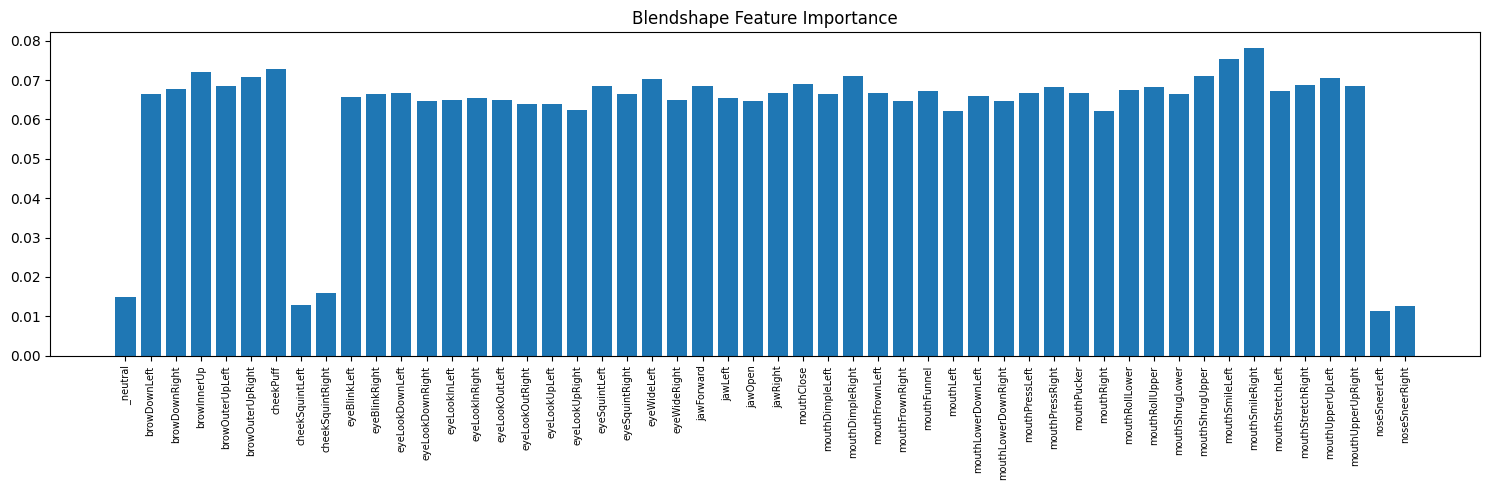

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# get blendshape names from mediapipe
sample_img = (X_train[0] * 255).astype(np.uint8)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=sample_img)
result = detector.detect(mp_image)
blendshape_names = [bs.category_name for bs in result.face_blendshapes[0]]

# get model weights from first layer — shows which blendshapes matter most
weights = model4.dense1.weight.detach().cpu().numpy()  # shape (512, 52)

# average absolute weight per blendshape
importance = np.abs(weights).mean(axis=0)  # shape (52,)

plt.figure(figsize=(15, 5))
plt.bar(range(52), importance)
plt.xticks(range(52), blendshape_names, rotation=90, fontsize=7)
plt.title("Blendshape Feature Importance")
plt.tight_layout()
plt.show()

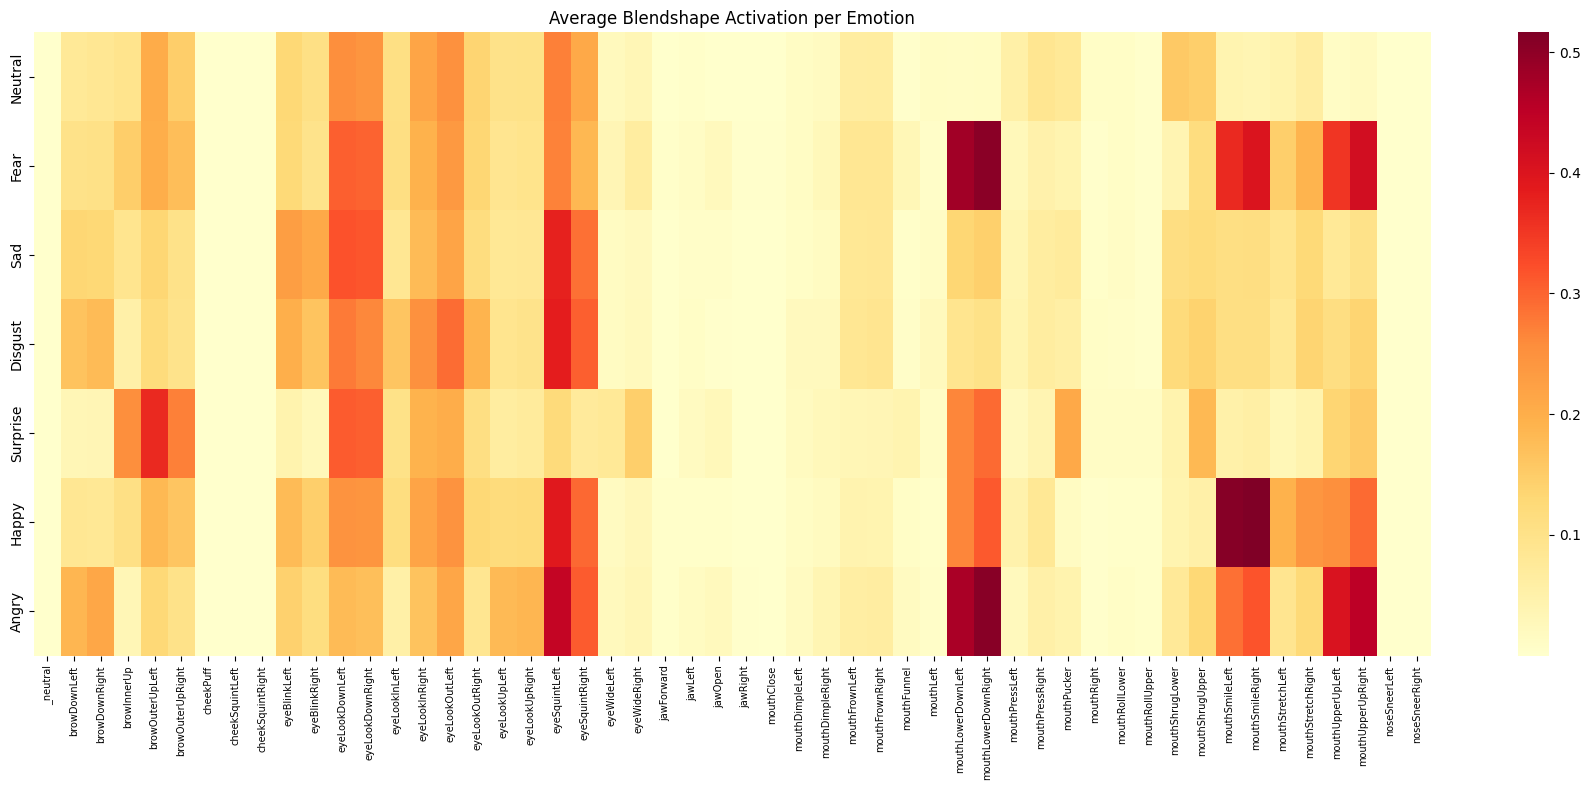

In [ ]:
# must match index order from your categories list!
emotion_names = ['Neutral', 'Fear', 'Sad', 'Disgust', 'Surprise', 'Happy', 'Angry']

avg_blendshapes = np.zeros((7, 52))
counts = np.zeros(7)

for blendshapes, label in zip(X_train_blendshapes, y_train_clean):
    avg_blendshapes[label] += blendshapes
    counts[label] += 1

avg_blendshapes /= counts[:, np.newaxis]

plt.figure(figsize=(18, 8))
sns.heatmap(
    avg_blendshapes,
    xticklabels=blendshape_names,
    yticklabels=emotion_names,
    cmap='YlOrRd',
    annot=False
)
plt.xticks(rotation=90, fontsize=7)
plt.title("Average Blendshape Activation per Emotion")
plt.tight_layout()
plt.show()

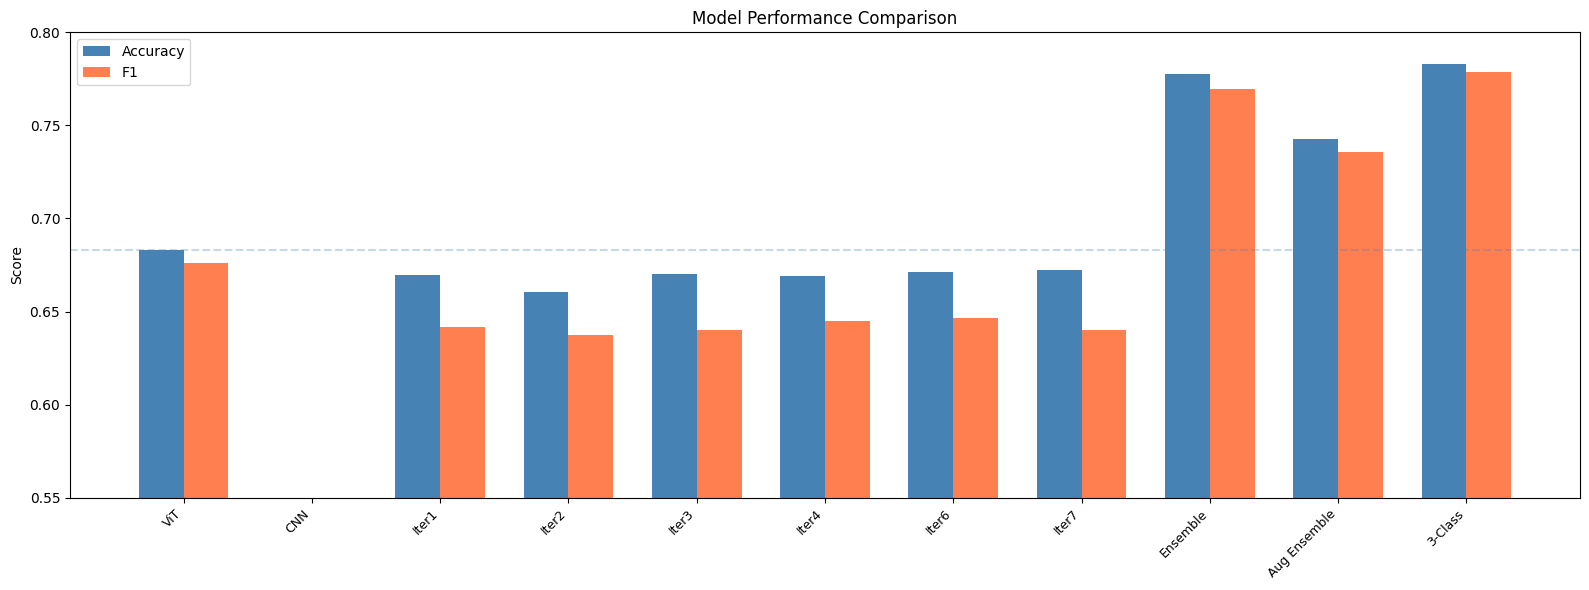

In [ ]:
#Grouped bar chart showing all model performances

import matplotlib.pyplot as plt
import numpy as np

models = ['ViT', 'CNN', 'Iter1', 'Iter2', 'Iter3', 'Iter4', 'Iter6', 'Iter7', 'Ensemble', 'Aug Ensemble', '3-Class']
accuracies = [vit_val_accuracy, val_accuracy, m1_val_accuracy, m2_val_accuracy, m3_val_accuracy,
              m4_val_accuracy, m6_val_accuracy, m7_val_accuracy, final_acc, aug_acc, acc_3]
f1s = [vit_val_f1, val_f1, m1_val_f1, m2_val_f1, m3_val_f1,
       m4_val_f1, m6_val_f1, m7_val_f1, final_f1, aug_f1, f1_3]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1s, width, label='F1', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(0.55, 0.80)
ax.axhline(y=vit_val_accuracy, color='steelblue', linestyle='--', alpha=0.3, label='ViT baseline')
plt.tight_layout()
plt.show()

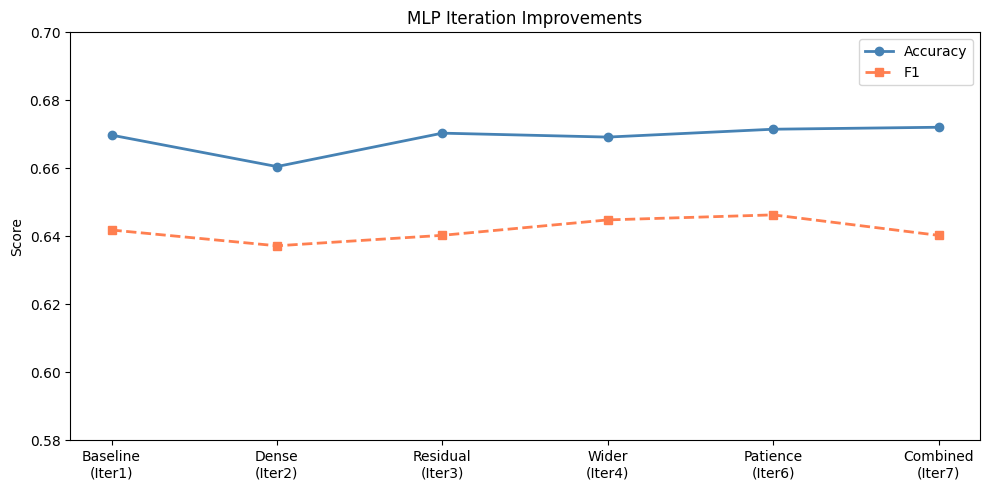

In [ ]:
#Evolution of Mediapipe Models

iter_names = ['Baseline\n(Iter1)', 'Dense\n(Iter2)', 'Residual\n(Iter3)', 'Wider\n(Iter4)', 'Patience\n(Iter6)', 'Combined\n(Iter7)']
iter_f1s = [m1_val_f1, m2_val_f1, m3_val_f1, m4_val_f1, m6_val_f1, m7_val_f1]
iter_accs = [m1_val_accuracy, m2_val_accuracy, m3_val_accuracy, m4_val_accuracy, m6_val_accuracy, m7_val_accuracy]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(iter_names, iter_accs, 'o-', color='steelblue', label='Accuracy', linewidth=2)
ax.plot(iter_names, iter_f1s, 's--', color='coral', label='F1', linewidth=2)
ax.set_title('MLP Iteration Improvements')
ax.set_ylabel('Score')
ax.legend()
ax.set_ylim(0.58, 0.70)
plt.tight_layout()
plt.show()

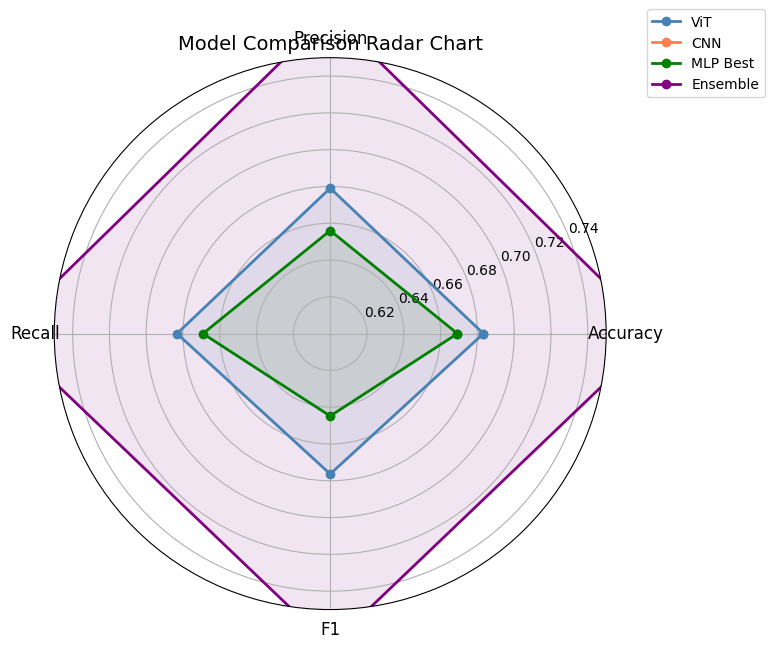

In [ ]:
#Radar chart of all models

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories_radar = ['Accuracy', 'Precision', 'Recall', 'F1']
models_radar = {
    'ViT': [vit_val_accuracy, vit_val_precision, vit_val_recall, vit_val_f1],
    'CNN': [val_accuracy, val_precision, val_recall, val_f1],
    'Best MediaPipe': [m4_val_accuracy, m4_val_precision, m4_val_recall, m4_val_f1],
    'Ensemble': [final_acc, final_prec, final_rec, final_f1],
}

angles = np.linspace(0, 2*np.pi, len(categories_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['steelblue', 'coral', 'green', 'purple']

for (model, values), color in zip(models_radar.items(), colors):
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories_radar, fontsize=12)
ax.set_ylim(0.6, 0.75)
ax.set_title('Model Comparison Radar Chart', fontsize=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()